# Day-to-day evolution of (ridepooling) supply and demand
Module for simulating ridesourcing evolution, including pooled rides

Contribution by Arjan de Ruijter - a.j.f.deruijter@tudelft.nl

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys # add MaaSSim and MaaSSim/MaaSSim to path (not needed if already in path)
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from MaaSSim.utils import save_config, get_config, load_G, generate_demand, initialize_df, empty_series, \
    slice_space, test_space, read_requests_csv
from MaaSSim.maassim import Simulator
from MaaSSim.data_structures import structures as inData
from MaaSSim.d2d_sim import *
from MaaSSim.d2d_demand import *
from MaaSSim.d2d_supply import *
from MaaSSim.d2d_shared import prep_shared_rides
from MaaSSim.decisions import dummy_False
from MaaSSim.exmas import main

In [3]:
import pandas as pd
import zipfile
import logging
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import random
# import ExMAS
plt.style.use('ggplot')
np.random.seed(0)
random.seed(0)

In [4]:
# Load config
params = get_config('../../data/config/delft.json')  # load configuration
params.paths.albatross = '../../data/albatross'

In [5]:
# Experiment replications and number of threads to be used
params.parallel.nReplications = 1
params.parallel.nThread = 1

# Main experimental settings
params.nP = 500 # travellers
params.nV = 50 # drivers
params.nD = 5 # days
params.simTime = 2 # hours

In [6]:
# Other day-to-day settings
params.evol.drivers.kappa = 0.2 # learning weight (supply-side)
params.evol.drivers.res_wage.mean = 25 #euros/h
params.evol.drivers.gini = 0.35 # gini coefficient used to establish sigma parameter of log-norm distribution of res wage
params.evol.drivers.init_inc_ratio = 1 #expected income of informed drivers at start of sim as ratio of res wage

params.evol.drivers.inform.prob_start = 1 # probability of being informed at start of sim
params.evol.drivers.inform.beta = 0.1 # information transmission rate
params.evol.drivers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced income used in signal

params.evol.drivers.regist.prob_start = 1 # probability of being registered if informed at start of sim
params.evol.drivers.regist.beta = 0.2 # registration choice model parameter
params.evol.drivers.regist.cost_comp = 20 # daily share of registration costs (euros)
params.evol.drivers.regist.samp = 0.5 # probability of making (de)regist decision
params.evol.drivers.regist.min_work_exp = 0 # Working experience required before deregistration is possible
params.evol.drivers.regist.min_days = 5 # Minimum number of registered days before driver can deregister

params.evol.drivers.particip.beta = 0.1 # participation choice model parameter
params.evol.drivers.particip.probabilistic = True # stochasticity in participation choice

params.evol.travellers.inform.prob_start = 1 # probability that traveller is informed at start of sim
params.evol.travellers.inform.beta = 0.1 # information transmission rate (demand-side)
params.evol.travellers.inform.start_wait = 0 # expected waiting time at start of simulation
params.evol.travellers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced waiting time used in signal
params.evol.travellers.reject_penalty = 30 * 60 # seconds
params.evol.travellers.kappa = 0.2 # learning weight (demand-side)
params.evol.travellers.min_prob = 0.05 # filtering criterion, when probability is lower when waiting time is zero, never consider RS

params.evol.travellers.mode_pref.mean_vot = 10 # Mean VoT in euro/h
params.evol.travellers.mode_pref.access_multip = 2 # Multiplier of access time compared to in-vehicle time
params.evol.travellers.mode_pref.wait_multip = 2.5 # Multiplier of waiting time compared to in-vehicle time
params.evol.travellers.mode_pref.bike_multip = 2 # Multiplier of biking time compared to in-vehicle time
params.evol.travellers.mode_pref.beta_cost = -0.1592 # util/euro
params.evol.travellers.mode_pref.transfer_pen = 5 * 60 # seconds, to be added to IVT for each transfer
params.evol.travellers.mode_pref.ASC_car = 0 # util, rel to bike
params.evol.travellers.mode_pref.ASC_rs = 0
params.evol.travellers.mode_pref.ASC_pt =  0
params.evol.travellers.mode_pref.ASC_car_sd = 0 # standard deviation in ASCs
params.evol.travellers.mode_pref.ASC_rs_sd = 0
params.evol.travellers.mode_pref.ASC_pt_sd = 0
params.evol.travellers.mode_pref.ASC_bike_sd = 0
params.evol.travellers.mode_pref.gini = params.evol.drivers.gini

# Financial settings
params.platforms.base_fare = 1 #euro
params.platforms.fare = 1 #euro/km
params.platforms.min_fare = 0 # euro
params.platforms.comm_rate = 0.05 #rate
params.drivers.fuel_costs = 0.25 #euro/km

# Properties alternative modes
params.alt_modes.pt.option = False
params.alt_modes.pt.base_fare = 0.99 # euro
params.alt_modes.pt.km_fare = 0.174 # euro/km
params.alt_modes.car.km_cost = 0.5 # euro/km
params.alt_modes.car.diff_parking = True # different parking tariffs in city
params.alt_modes.car.park_cost = 7.5 # euro
params.alt_modes.car.park_cost_center = 15 # euro
params.alt_modes.car.access_time = 10 * 60 # s
params.speeds.bike = (1/2.5) * params.speeds.ride # m/s

# Regulation
params.platforms.reg_cap = np.inf # registration cap
params.platforms.ptcp_cap = np.inf # daily participation cap

# Demand settings
# params.demand_structure.origins_dispertion = -0.0003
# params.demand_structure.destinations_dispertion = -0.0003
params.dist_threshold_min = 2000 # min dist
# params.dist_threshold = 100000 # max dist

# Start time
# params.t0 = pd.Timestamp.now()
params.t0 = pd.Timestamp(2021, 11, 1, 9)

In [7]:
# Pooling settings
params.shareability.offered = True
params.shareability.min_discount = 0.3 # fraction of solo fare
params.shareability.add_discount = 0.3 # fraction of solo fare
params.shareability.shared_discount = 0.35 # as considered by platform in determ. of feasible rides (fraction of solo fare)
params.shareability.delay_value = 1
params.shareability.WtS_mean = 1.5 # Actual (mean) WtS multipl. in population
params.shareability.WtS = 1 # Willingness to share multipl. as considered by platform in determining feasible rides
params.shareability.WtS_std = 0 # St. dev. of WtS in population
params.shareability.matching_obj = 'u_pax' #minimize VHT for vehicles
params.shareability.pax_delay = 0 # additional delay for picking up travs
params.shareability.max_delay = 10 * 60 # max. allowed delay in pooled rides (sec.)
params.shareability.horizon = 600
params.shareability.max_degree = 2
params.shareability.share = 1
params.shareability.without_matching = True

In [8]:
# Compute (other) input parameters in ExMAS
params.shareability.avg_speed = params.speeds.ride
params.shareability.price = params.platforms.fare #eur/km
params.shareability.nP = params.nP
params.shareability.VoT = params.evol.travellers.mode_pref.mean_vot / 3600 # convert eur/h to eur/s

In [9]:
inData = load_G(inData, params, stats=True, set_t=False)  # download graph for the 'params.city' and calc the skim matrices
if params.alt_modes.car.diff_parking:
    inData = diff_parking(inData) # determine which nodes are in center

In [10]:
inData = generate_demand(inData, params, avg_speed = True)

In [11]:
# Load processed Albatross file, the OTP result, and compute PT fares
# inData = load_albatross_proc(inData, params, avg_speed = True)
# inData.requests = inData.requests.drop(['orig_geo', 'dest_geo', 'origin_y', 'origin_x', 'destination_y', 'destination_x', 'time'], axis = 1)
# inData.pt_itinerary = load_OTP_result(params)
# inData = consist_OTP_alba(inData, params)

In [12]:
# Prepare supply and demand attributes
inData.passengers = prefs_travs(inData, params)
all_pax = mode_filter(inData, params)
inData.passengers = all_pax[all_pax.mode_choice == "day-to-day"]
inData.requests = inData.requests[inData.requests.pax_id.isin(inData.passengers.index)]
if params.alt_modes.pt.option:
    inData.pt_itinerary = inData.pt_itinerary[inData.pt_itinerary.pax_id.isin(inData.passengers.index)]
    inData.passengers.reset_index(drop=True, inplace=True)
    inData.requests.reset_index(drop=True, inplace=True)
    inData.pt_itinerary.reset_index(drop=True, inplace=True)
inData.requests['pax_id'] = inData.requests.index
inData.pt_itinerary['pax_id'] = inData.pt_itinerary.index
inData.passengers['informed'] = np.random.rand(len(inData.passengers)) < params.evol.travellers.inform.prob_start
inData.passengers['expected_wait'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_wait_pool'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_pool_disc'] = params.shareability.min_discount
inData.passengers['expected_pool_detour'] = 0
fixed_supply = generate_vehicles_d2d(inData, params)
inData.vehicles = fixed_supply.copy()
inData.vehicles.platform = inData.vehicles.apply(lambda x: 0, axis = 1)
inData.passengers.platforms = inData.passengers.apply(lambda x: [0], axis = 1)
inData.requests['platform'] = inData.requests.apply(lambda row: inData.passengers.loc[row.name].platforms[0], axis = 1) 
inData.platforms = pd.concat([inData.platforms,pd.DataFrame(columns=['base_fare','comm_rate','min_fare'])])
inData.platforms = initialize_df(inData.platforms)
inData.platforms.loc[0]=[params.platforms.fare,'Uber',30,params.platforms.base_fare,params.platforms.comm_rate,params.platforms.min_fare,]

In [13]:
inData = main(inData, params.shareability, plot=False) # create shareability graph (ExMAS) 

20-04-23 10:29:07-INFO-Initializing pairwise trip shareability between 500 and 500 trips.
20-04-23 10:29:07-INFO-creating combinations
20-04-23 10:29:08-INFO-249500	 nR*(nR-1)
20-04-23 10:29:15-INFO-Reduction of feasible pairs by 97.90%
20-04-23 10:29:15-INFO-Degree 2 	Completed


In [14]:
# Day-to-day simulation (incl. processing)
sim = Simulator(inData, params=params,
                    kpi_veh = D2D_veh_exp,
                    kpi_pax = d2d_kpi_pax,
                    f_driver_out = D2D_driver_out,
                    f_trav_out = d2d_no_request,
                    f_trav_mode = dummy_False,
                    logger_level=logging.WARNING)  # initialize

evol_micro = init_d2d_dotmap(params)
plf_stats = pd.DataFrame(columns = ['profit','veh_dist','pax_dist'])
for day in range(params.get('nD', 1)):  # run iterations
    inData.passengers = mode_preday(inData, params)
    temp_rides = inData.sblts.rides.copy()
    temp_reqs = inData.sblts.requests.copy()
    
    rs_users = inData.passengers[(inData.passengers.mode_day == 'rs') | (inData.passengers.mode_day == 'pool')].index.tolist()
    poolers = inData.passengers[inData.passengers.mode_day == 'pool'].index.tolist()
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled trips for individuals opting for private ride
    inData.sblts.requests = inData.sblts.requests[inData.sblts.requests.apply(lambda x: x.pax_id in rs_users, axis=1)]
    
    inData = prep_shared_rides(inData, params.shareability)  # prepare schedules
    sim.make_and_run(run_id=day)  # prepare and SIM
    sim.output()  # calc results
    sim.last_res = sim.res[day].copy()
    del sim.res[day]

    drivers_summary = update_d2d_drivers(sim=sim,params=params)
    travs_summary = update_d2d_travellers(sim=sim,params=params)
    
    exp_df = update_work_exp(inData, drivers_summary)
    inData.vehicles.work_exp = exp_df.work_exp
    inData.days_since_reg = exp_df.days_since_reg

    res_inf_driver = wom_driver(inData, params = params)
    inData.vehicles.informed = res_inf_driver
    inData.vehicles.expected_income = learning_unregist(inData, drivers_summary, params = params)
    
    res_regist = platform_regist(inData, drivers_summary, params = params)
    inData.vehicles.registered = res_regist.registered
    inData.vehicles.work_exp = res_regist.work_exp
    inData.vehicles.pos = fixed_supply.pos
    inData.vehicles.rejected_reg = res_regist.rejected_reg
    
    res_inf_trav = wom_trav(inData, travs_summary, params = params)
    inData.passengers.informed = res_inf_trav.informed
    inData.passengers.expected_wait = res_inf_trav.perc_wait
    inData.passengers.expected_wait_pool = res_inf_trav.perc_wait_pool
    inData.passengers.expected_pool_disc = res_inf_trav.perc_disc
    inData.passengers.expected_pool_detour = res_inf_trav.perc_detour
    
    inData.sblts.rides = temp_rides.copy()
    inData.sblts.requests = temp_reqs.copy()
    
    evol_micro = d2d_summary_day(evol_micro, drivers_summary, travs_summary, day)
    evol_micro = d2d_summ_pooling(evol_micro, travs_summary)
    row = {'profit': sim.last_res.veh_kpi.REVENUE.loc['sum'] / (1 - params.platforms.comm_rate), 'veh_dist': sim.last_res.veh_kpi.DRIVING_DIST.loc['sum'], 'pax_dist': sim.last_res.pax_kpi.TRAVEL.loc['sum'] * params.speeds.ride / 1000}
    plf_stats = plf_stats.append(row, ignore_index=True)

20-04-23 10:29:15-WARNING-Setting up 2h simulation at 2021-11-01 08:00:09 for 50 vehicles and 500 passengers in Delft, Netherlands
20-04-23 10:29:35-WARNING-day 0: simulation time 15.4 s
20-04-23 10:29:36-WARNING-assertion tests for simulation results - passed
20-04-23 10:29:49-WARNING-day 1: simulation time 10.5 s
20-04-23 10:29:50-WARNING-assertion tests for simulation results - passed
20-04-23 10:30:02-WARNING-day 2: simulation time 9.6 s
20-04-23 10:30:03-WARNING-assertion tests for simulation results - passed
20-04-23 10:30:13-WARNING-day 3: simulation time 6.8 s
20-04-23 10:30:13-WARNING-assertion tests for simulation results - passed
20-04-23 10:30:21-WARNING-day 4: simulation time 5.3 s
20-04-23 10:30:21-WARNING-assertion tests for simulation results - passed


In [15]:
evol_micro, evol_agg = d2d_agg_statistics(evol_micro, params) # multi-day stats

In [16]:
# Save d2d stats to zip file
with zipfile.ZipFile('evol.zip', 'w') as csv_zip:
    csv_zip.writestr("evol_agg_supply.csv", evol_agg.supply.to_csv())
    csv_zip.writestr("evol_agg_demand.csv", evol_agg.demand.to_csv())

In [17]:
evol_agg.supply

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc
day,,,,,,,,,
0,50,50,0,28,0,50.539889,51.872048,50.539889,26.425607
1,50,50,0,21,0,47.689888,49.804478,47.689888,22.544857
2,50,50,0,26,0,45.400079,37.152604,45.400079,14.275404
3,50,50,0,15,0,43.020851,36.255964,43.020851,16.045867
4,50,50,0,16,0,41.808245,27.326336,41.808245,8.946281


In [21]:
evol_agg.demand

,inform,requests,req_solo,req_pool,gets_offer_solo,gets_offer_pooling,act_shared,mean_wait_solo,corr_mean_wait_solo,mean_wait_pooling,...,perc_wait,perc_wait_req,perc_wait_pool,mean_disc,perc_disc,mean_detour,perc_detour,bike,car,pt
day,,,,,,,,,,,,,,,,,,,,,
0,500,304,135,169,135,169,166,188.200658,188.200658,120.986842,...,0.0000,0.0,0.000000,0.594675,0.300000,46.460526,0.00000,162,34,0
1,500,177,113,64,113,64,58,175.474576,175.474576,77.254237,...,8.1732,0.0,20.153425,0.571875,0.319920,39.033898,5.64960,286,37,0
2,500,135,86,49,86,49,46,120.548148,120.548148,57.859259,...,15.1272,0.0,27.520159,0.581633,0.326736,45.948148,8.40952,331,34,0
3,500,83,64,19,64,19,14,144.867470,144.867470,40.903614,...,18.5124,0.0,34.557639,0.521053,0.332045,24.421687,10.88200,401,16,0
4,500,47,39,8,39,8,2,120.829787,120.829787,14.702128,...,21.9640,0.0,35.659608,0.375000,0.333653,4.829787,11.69160,445,8,0


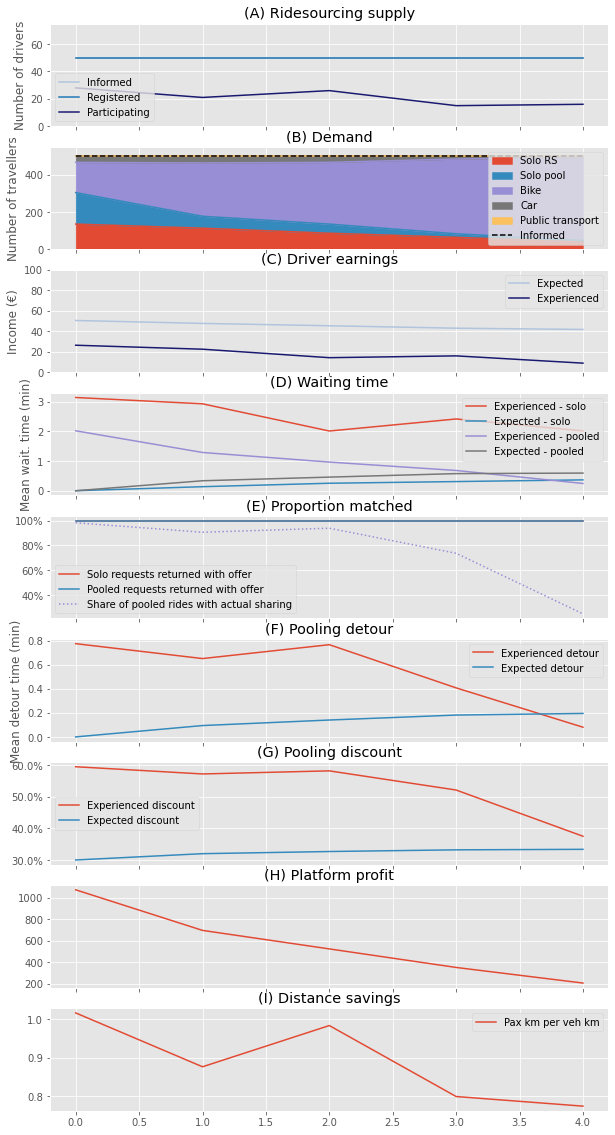

In [22]:
# Plot evolution of main performance indicators
fig, axes = plt.subplots(nrows=9, ncols=1, figsize = (10,20), sharex = True)
evol_agg.supply[['inform','regist','particip']].plot(ax = axes[0], color=['lightsteelblue','tab:blue','midnightblue'])
axes[0].set_title('(A) Ridesourcing supply')
axes[0].legend(['Informed','Registered','Participating'])
axes[0].set_ylim([0,params.nV + 25])
axes[0].set_ylabel('Number of drivers')
evol_agg.supply[['mean_perc_inc','mean_exp_inc']].plot(ax = axes[2], color=['lightsteelblue','midnightblue'])
axes[2].set_title('(C) Driver earnings')
axes[2].legend(['Expected','Experienced'])
axes[2].set_ylim([0,math.ceil(max(evol_agg.supply.mean_perc_inc.max(),evol_agg.supply.mean_exp_inc.max())/50)*50])
axes[2].set_ylabel('Income (\u20ac)')

evol_agg.demand[['req_solo','req_pool','bike','car','pt']].plot.area(ax = axes[1])
h,l = axes[1].get_legend_handles_labels()
evol_agg.demand['inform'].plot(ax = axes[1], color = 'black', linestyle = 'dashed', label = 'informed')
line = Line2D([0], [0],color='black', linestyle ='dashed')
axes[1].set_title('(B) Demand')
axes[1].set_ylim([0,len(inData.passengers) * 1.1])
axes[1].set_ylabel('Number of travellers')
h.extend([line])
axes[1].legend(labels=["Solo RS","Solo pool","Bike","Car","Public transport","Informed"], handles=h)

evol_agg.demand['mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - solo')
# evol_agg.demand['corr_mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - solo')
evol_agg.demand['perc_wait'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - solo')
evol_agg.demand['mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - pooled')
# evol_agg.demand['corr_mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - pooled')
evol_agg.demand['perc_wait_pool'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - pooled')
axes[3].legend()
axes[3].set_title('(D) Waiting time')
axes[3].set_ylabel('Mean wait. time (min)')

evol_agg.demand['proport_match_solo'] = evol_agg.demand.gets_offer_solo / evol_agg.demand.req_solo * 100
evol_agg.demand['proport_match_pool'] = evol_agg.demand.gets_offer_pooling / evol_agg.demand.req_pool * 100
evol_agg.demand['act_shared_rel'] = evol_agg.demand.act_shared / evol_agg.demand.gets_offer_pooling * 100
evol_agg.demand['proport_match_solo'].plot(ax = axes[4], label='Solo requests returned with offer')
evol_agg.demand['proport_match_pool'].plot(ax = axes[4], label='Pooled requests returned with offer')
evol_agg.demand['act_shared_rel'].plot(ax = axes[4], label='Share of pooled rides with actual sharing', linestyle = 'dotted')
axes[4].legend()
axes[4].set_title('(E) Proportion matched')
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter())

evol_agg.demand['mean_detour'].apply(lambda x: 1/60 * x).plot(ax = axes[5], label='Experienced detour')
evol_agg.demand['perc_detour'].apply(lambda x: 1/60 * x).plot(ax = axes[5], label='Expected detour')
axes[5].legend()
axes[5].set_title('(F) Pooling detour')
axes[5].set_ylabel('Mean detour time (min)')

evol_agg.demand['mean_disc'].apply(lambda x: 100 * x).plot(ax = axes[6], label='Experienced discount')
evol_agg.demand['perc_disc'].apply(lambda x: 100 * x).plot(ax = axes[6], label='Expected discount')
axes[6].legend()
axes[6].set_title('(G) Pooling discount')
axes[6].yaxis.set_major_formatter(mtick.PercentFormatter())

plf_stats['profit'].plot(ax = axes[7], label='Platform profit')
axes[7].set_title('(H) Platform profit')

plf_stats['dist_ratio'] = plf_stats.pax_dist / plf_stats.veh_dist
plf_stats['dist_ratio'].plot(ax = axes[8], label='Pax km per veh km')
axes[8].legend()
axes[8].set_title('(I) Distance savings')

plt.savefig('d2d-evo.png')

---

In [ ]:
sim.last_res.veh_exp

In [ ]:
sim.last_res.pax_exp

In [ ]:
inData.sblts.R[1]

In [ ]:
inData.sblts.rides

In [ ]:
inData.sblts.requests

In [ ]:
sim.runs[0].rides

In [ ]:
sim.runs[0].trips

In [ ]:
inData.sblts.SINGLES

In [ ]:
xyz = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
xyz = xyz[xyz.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled trips for individuals opting for private ride
xyz
# poolers

In [ ]:
xyz = inData.sblts.schedule.copy()
xyz['pooling_reqs'] = xyz.apply(lambda x: any(i in travs_summary[travs_summary.chosen_mode == 'pool'].index.to_list() for i in x.indexes) and travs_summary.gets_offer.loc[x.indexes[0]], axis=1)
xyz[xyz.pooling_reqs]